# Dự đoán theo SHAPE+KMeans

## 1. load và setup dataset

In [2]:
# core
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    mean_squared_error
)

# statsmodels (forecast)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# =========================
# PROJECT IMPORT (OPTIONAL)
# =========================

# chỉ dùng nếu bạn có thư mục src thật
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

try:
    from src.data_loader import load_data, load_raw_data, save_file
    from src.splitting import time_train_test_split
    from src.evaluation import evaluate
    print("✔ Loaded custom src modules")
except ImportError:
    print("⚠️ src modules not found (OK if not using them)")

# =========================
# SETTINGS
# =========================

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

✔ Loaded custom src modules
Python: 3.10.20
Pandas: 2.3.3
NumPy: 2.2.5


## 2. sử dụng recursive multi-step future forecasting

**pipeline:**
customers
→ cluster
→ total cluster demand
→ daily aggregation
→ recursive forecasting
→ bottom-up aggregation
→ total system load


CLUSTER 0
train days: 1096
test days : 365


c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\

╒═══════════╤════════════════╤══════════╤═════════╤═════════╤════════════╤═════════╕
│   cluster │ model          │      mae │    rmse │    mape │   accuracy │   smape │
╞═══════════╪════════════════╪══════════╪═════════╪═════════╪════════════╪═════════╡
│         0 │ naive          │ 10449.5  │ 14967.8 │ 16.4181 │    83.5819 │ 19.1638 │
├───────────┼────────────────┼──────────┼─────────┼─────────┼────────────┼─────────┤
│         0 │ seasonal naive │ 11486.6  │ 15744.2 │ 18.7304 │    81.2696 │ 21.946  │
├───────────┼────────────────┼──────────┼─────────┼─────────┼────────────┼─────────┤
│         0 │ holt-winters   │  8783.08 │ 11257.6 │ 15.5812 │    84.4188 │ 15.7247 │
├───────────┼────────────────┼──────────┼─────────┼─────────┼────────────┼─────────┤
│         0 │ sarima         │  9681.91 │ 13274.7 │ 15.7305 │    84.2695 │ 17.5393 │
╘═══════════╧════════════════╧══════════╧═════════╧═════════╧════════════╧═════════╛

BEST MODEL CLUSTER 0: holt-winters | RMSE = 11257.5761


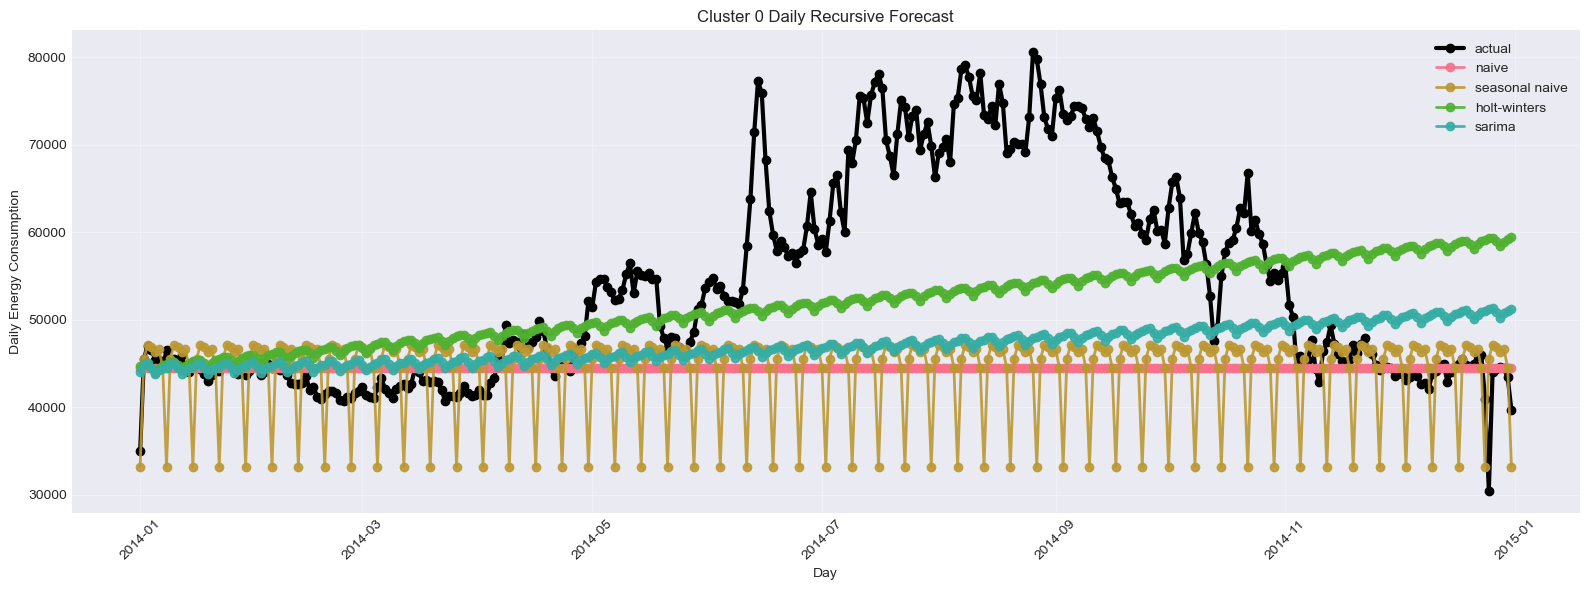


CLUSTER 1
train days: 1096
test days : 365


c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\

╒═══════════╤════════════════╤═════════╤══════════╤═════════╤════════════╤═════════╕
│   cluster │ model          │     mae │     rmse │    mape │   accuracy │   smape │
╞═══════════╪════════════════╪═════════╪══════════╪═════════╪════════════╪═════════╡
│         1 │ naive          │ 6041.2  │  8132.07 │  9.1834 │    90.8166 │  9.8111 │
├───────────┼────────────────┼─────────┼──────────┼─────────┼────────────┼─────────┤
│         1 │ seasonal naive │ 8218.42 │ 12309.1  │ 12.8637 │    87.1363 │ 14.959  │
├───────────┼────────────────┼─────────┼──────────┼─────────┼────────────┼─────────┤
│         1 │ holt-winters   │ 4761.89 │  6535.73 │  7.33   │    92.67   │  7.6136 │
├───────────┼────────────────┼─────────┼──────────┼─────────┼────────────┼─────────┤
│         1 │ sarima         │ 6738.28 │  8829.13 │ 10.2408 │    89.7592 │ 11.0617 │
╘═══════════╧════════════════╧═════════╧══════════╧═════════╧════════════╧═════════╛

BEST MODEL CLUSTER 1: holt-winters | RMSE = 6535.7276


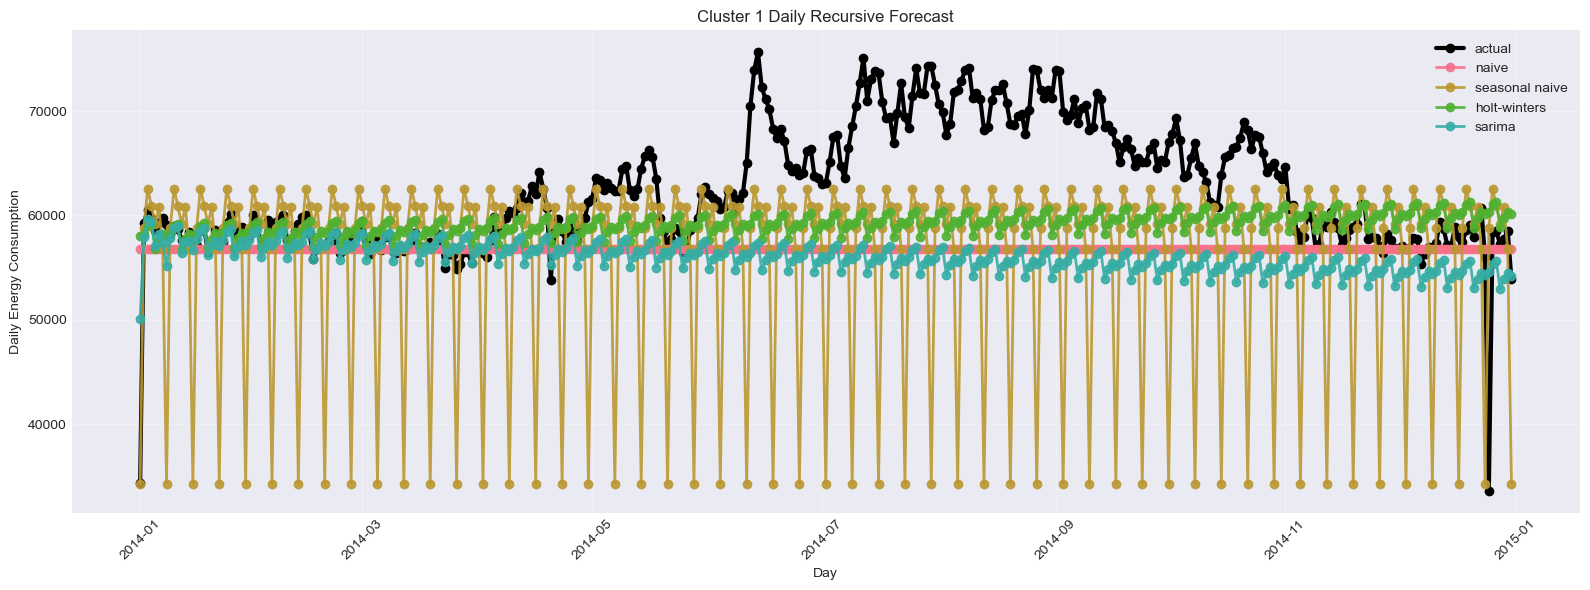


CLUSTER 2
train days: 1096
test days : 365


c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\XPS\anaconda3\envs\time\lib\site-packages\statsmodels\base\

╒═══════════╤════════════════╤══════════╤═════════╤═════════╤════════════╤═════════╕
│   cluster │ model          │      mae │    rmse │    mape │   accuracy │   smape │
╞═══════════╪════════════════╪══════════╪═════════╪═════════╪════════════╪═════════╡
│         2 │ naive          │ 12627.6  │ 14305.2 │ 21.1441 │    78.8559 │ 23.7267 │
├───────────┼────────────────┼──────────┼─────────┼─────────┼────────────┼─────────┤
│         2 │ seasonal naive │ 13941.6  │ 17980.3 │ 23.6987 │    76.3013 │ 28.6966 │
├───────────┼────────────────┼──────────┼─────────┼─────────┼────────────┼─────────┤
│         2 │ holt-winters   │  6742.79 │  8668.6 │ 12.825  │    87.175  │ 11.9053 │
├───────────┼────────────────┼──────────┼─────────┼─────────┼────────────┼─────────┤
│         2 │ sarima         │ 28974.7  │ 32509.3 │ 48.7757 │    51.2243 │ 70.2664 │
╘═══════════╧════════════════╧══════════╧═════════╧═════════╧════════════╧═════════╛

BEST MODEL CLUSTER 2: holt-winters | RMSE = 8668.6049


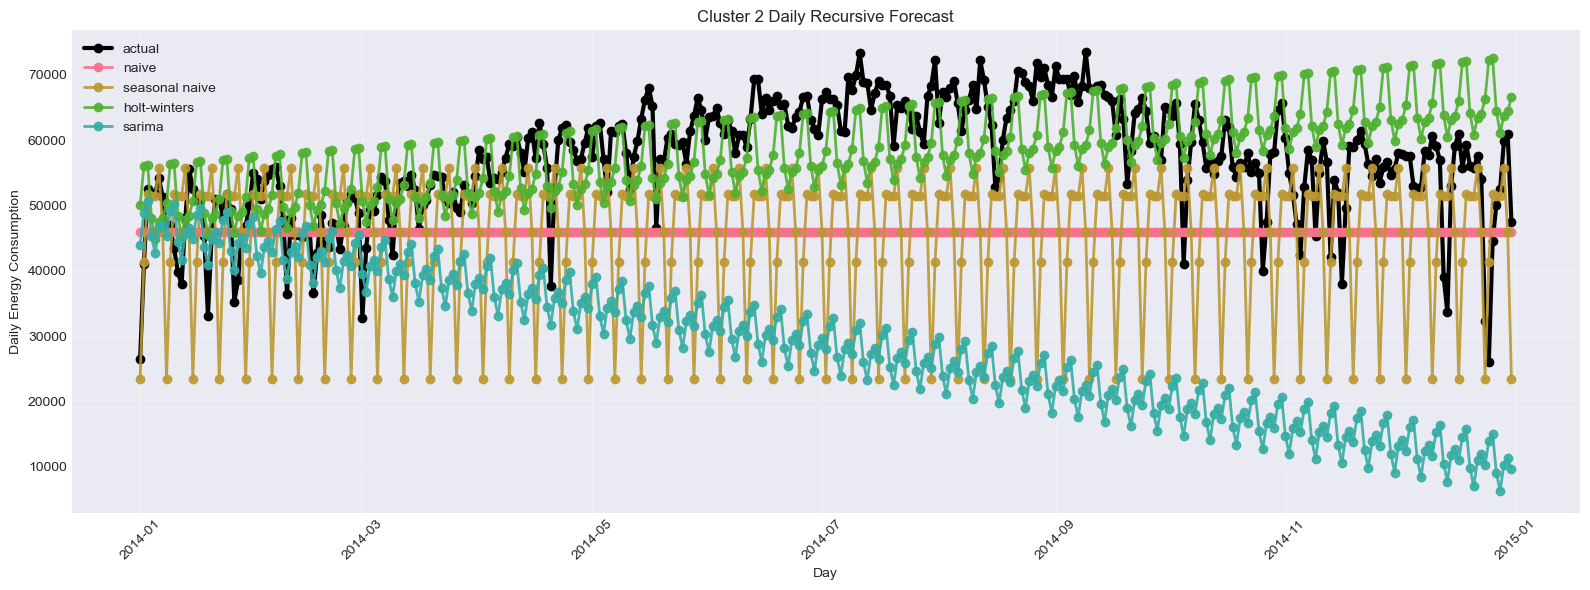


TOTAL SYSTEM RESULTS
╒════════════════╤═════════╤═════════╤═════════╤════════════╤═════════╕
│ model          │     mae │    rmse │    mape │   accuracy │   smape │
╞════════════════╪═════════╪═════════╪═════════╪════════════╪═════════╡
│ naive          │ 28109.9 │ 35965   │ 14.9272 │    85.0728 │ 16.6658 │
├────────────────┼─────────┼─────────┼─────────┼────────────┼─────────┤
│ seasonal naive │ 32287.3 │ 43612.5 │ 17.5917 │    82.4083 │ 20.6971 │
├────────────────┼─────────┼─────────┼─────────┼────────────┼─────────┤
│ holt-winters   │ 18438.7 │ 23477.8 │ 10.4593 │    89.5407 │ 10.4757 │
├────────────────┼─────────┼─────────┼─────────┼────────────┼─────────┤
│ sarima         │ 42526.9 │ 50867.4 │ 22.9515 │    77.0485 │ 27.0681 │
╘════════════════╧═════════╧═════════╧═════════╧════════════╧═════════╛

BEST OVERALL MODEL: holt-winters | RMSE = 23477.8117


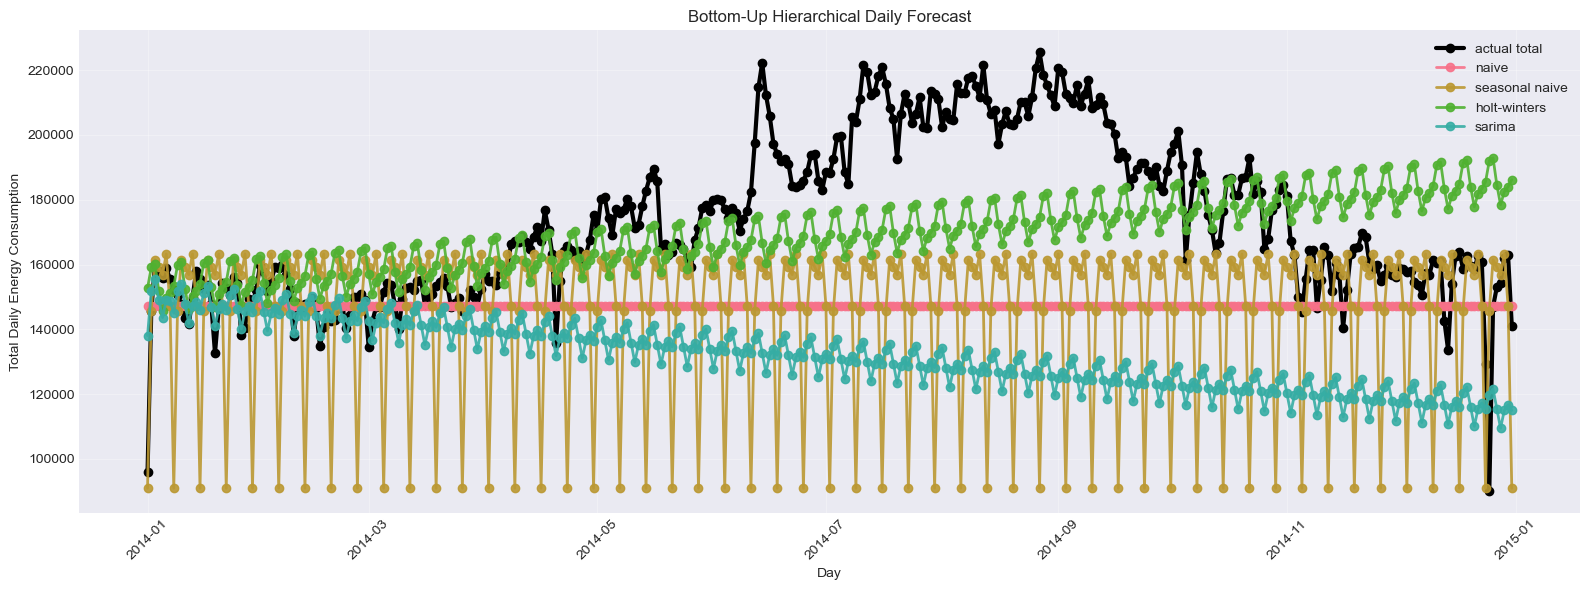

In [3]:
def calc_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    nonzero = y_true != 0

    if nonzero.sum() > 0:

        mape = np.mean(
            np.abs(
                (y_true[nonzero] - y_pred[nonzero])
                / y_true[nonzero]
            )
        ) * 100

    else:
        mape = np.nan

    smape = np.mean(
        2 * np.abs(y_pred - y_true)
        / (
            np.abs(y_true)
            + np.abs(y_pred)
            + 1e-8
        )
    ) * 100

    return mae, rmse, mape, smape


def recursive_naive_future(history, horizon):

    h = list(history)

    preds = []

    for _ in range(horizon):

        pred = h[-1]

        preds.append(pred)

        h.append(pred)

    return np.array(preds)


def recursive_snaive_future(
    history,
    horizon,
    season=7
):

    h = list(history)

    preds = []

    for _ in range(horizon):

        if len(h) >= season:
            pred = h[-season]
        else:
            pred = h[-1]

        preds.append(pred)

        h.append(pred)

    return np.array(preds)


def recursive_hw_future(
    history,
    horizon,
    season=7,
    refit_every=1
):

    h = list(history)

    preds = []

    fit = None

    for i in range(horizon):

        if fit is None or i % refit_every == 0:

            fit = ExponentialSmoothing(
                h,
                trend="add",
                seasonal="add",
                seasonal_periods=season,
                initialization_method="estimated"
            ).fit(optimized=True)

        pred = fit.forecast(1)[0]

        preds.append(pred)

        h.append(pred)

    return np.array(preds)


def recursive_sarima_future(
    history,
    horizon,
    season=7,
    refit_every=1
):

    h = list(history)

    preds = []

    fit = None

    for i in range(horizon):

        if fit is None or i % refit_every == 0:

            model = SARIMAX(
                h,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, season),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit(disp=False)

        pred = fit.forecast(1)[0]

        preds.append(pred)

        h.append(pred)

    return np.array(preds)


base_dir = os.path.dirname(os.getcwd())

base_root = os.path.join(
    base_dir,
    "data",
    "processed",
    "shape_kmeans"
)

train_path = os.path.join(base_root, "train")
test_path = os.path.join(base_root, "test")


n_clusters = 3
season = 7


all_results = []

cluster_preds = {
    "naive": [],
    "seasonal naive": [],
    "holt-winters": [],
    "sarima": []
}

cluster_truth = []


for c in range(n_clusters):

    print(f"\nCLUSTER {c}")

    train_file = os.path.join(
        train_path,
        f"cluster_{c}.csv"
    )

    test_file = os.path.join(
        test_path,
        f"cluster_{c}.csv"
    )

    train_df = pd.read_csv(
        train_file,
        index_col=0,
        parse_dates=True
    )

    test_df = pd.read_csv(
        test_file,
        index_col=0,
        parse_dates=True
    )

    train_df = (
        train_df
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    test_df = (
        test_df
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    y_train = (
        train_df.mean(axis=1)
        .resample("D")
        .sum()
        .ffill()
        .bfill()
    )

    y_test = (
        test_df.mean(axis=1)
        .resample("D")
        .sum()
        .ffill()
        .bfill()
    )

    print("train days:", len(y_train))
    print("test days :", len(y_test))

    mu = y_train.mean()

    sigma = y_train.std() + 1e-8

    y_train_s = (
        (y_train - mu)
        / sigma
    )

    history = y_train_s.values

    horizon = len(y_test)

    pred_naive_s = recursive_naive_future(
        history,
        horizon
    )

    pred_snaive_s = recursive_snaive_future(
        history,
        horizon,
        season=season
    )

    pred_hw_s = recursive_hw_future(
        history,
        horizon,
        season=season,
        refit_every=1
    )

    pred_sarima_s = recursive_sarima_future(
        history,
        horizon,
        season=season,
        refit_every=1
    )

    preds = {

        "naive":
            pred_naive_s * sigma + mu,

        "seasonal naive":
            pred_snaive_s * sigma + mu,

        "holt-winters":
            pred_hw_s * sigma + mu,

        "sarima":
            pred_sarima_s * sigma + mu
    }

    for name in cluster_preds:

        cluster_preds[name].append(
            preds[name]
        )

    cluster_truth.append(
        y_test.values
    )

    y_true = y_test.values

    cluster_results = []

    for name, pred in preds.items():

        mae, rmse, mape, smape = calc_metrics(
            y_true,
            pred
        )

        cluster_results.append({

            "cluster": c,

            "model": name,

            "mae": mae,

            "rmse": rmse,

            "mape": mape,

            "accuracy":
                (
                    100 - mape
                    if np.isfinite(mape)
                    else np.nan
                ),

            "smape": smape
        })

    cluster_df = pd.DataFrame(
        cluster_results
    ).round(4)

    all_results.append(cluster_df)

    print(
        tabulate(
            cluster_df,
            headers="keys",
            tablefmt="fancy_grid",
            showindex=False
        )
    )

    best_model = cluster_df.loc[
        cluster_df["rmse"].idxmin()
    ]

    print(
        f"\nBEST MODEL CLUSTER {c}: "
        f"{best_model['model']} "
        f"| RMSE = {best_model['rmse']:.4f}"
    )

    plt.figure(figsize=(16, 6))

    plt.plot(
        y_test.index,
        y_test.values,
        color="black",
        linewidth=3,
        marker="o",
        label="actual"
    )

    for name, pred in preds.items():

        plt.plot(
            y_test.index,
            pred,
            linewidth=2,
            marker="o",
            alpha=0.9,
            label=name
        )

    plt.title(
        f"Cluster {c} Daily Recursive Forecast"
    )

    plt.xlabel("Day")

    plt.ylabel("Daily Energy Consumption")

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()


y_true_total = np.sum(
    np.vstack(cluster_truth),
    axis=0
)

final_preds = {

    name: np.sum(
        np.vstack(pred_list),
        axis=0
    )

    for name, pred_list
    in cluster_preds.items()
}


results = []

for name, pred in final_preds.items():

    mae, rmse, mape, smape = calc_metrics(
        y_true_total,
        pred
    )

    results.append({

        "model": name,

        "mae": mae,

        "rmse": rmse,

        "mape": mape,

        "accuracy":
            (
                100 - mape
                if np.isfinite(mape)
                else np.nan
            ),

        "smape": smape
    })

results_df = pd.DataFrame(
    results
).round(4)

print("\nTOTAL SYSTEM RESULTS")

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

best = results_df.loc[
    results_df["rmse"].idxmin()
]

print(
    f"\nBEST OVERALL MODEL: "
    f"{best['model']} "
    f"| RMSE = {best['rmse']:.4f}"
)


plt.figure(figsize=(16, 6))

sample_index = y_test.index

plt.plot(
    sample_index,
    y_true_total,
    color="black",
    linewidth=3,
    marker="o",
    label="actual total"
)

for name, pred in final_preds.items():

    plt.plot(
        sample_index,
        pred,
        linewidth=2,
        marker="o",
        alpha=0.9,
        label=name
    )

plt.title(
    "Bottom-Up Hierarchical Daily Forecast"
)

plt.xlabel("Day")

plt.ylabel("Total Daily Energy Consumption")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()